In [2]:
import os
import requests
import pandas as pd

API_KEY = os.environ.get("NREL_API_KEY")
if not API_KEY:
    raise RuntimeError(
        "Set the NREL_API_KEY environment variable before running this "
        "cell -- see the markdown cell above for how."
    )
    raise RuntimeError(
        "Set the NREL_EMAIL environment variable to your real email "
        "before running this cell -- the API rejects placeholder "
        "addresses. e.g. os.environ['NREL_EMAIL'] = 'you@example.com'"
    )

url = "https://developer.nlr.gov/api/nsrdb/v2/solar/himawari-download.csv"

# The Himawari endpoint does NOT accept a comma-separated year list
# (e.g. "names": "2019,2020") in a single request -- that fails.
# Fetch each year separately instead, then concatenate.
years = ["2019", "2020"]
frames = []

for year in years:
    params = {
        "api_key": API_KEY,
        "email":  os.environ.get("NREL_EMAIL", "saiyedfaiez@gmail.com"),
        "wkt": "POINT(75.9235 22.5297)",  # IIT Indore campus (longitude latitude)
        "names": year,
        "leap_day": "false",   # keeps every year a clean 365 days (matters for
                                # the day-of-year astronomy formulas used later)
        "interval": "10",
        "utc": "false",
        "mailing_list": "false",
    }

    response = requests.get(url, params=params)

    if response.status_code != 200 or response.headers.get("Content-Type", "").startswith("application/json"):
        print(f"Request failed for {year} -- response was not a CSV file:")
        print(response.text[:1000])
        raise RuntimeError(f"NLR API request failed for {year} with status {response.status_code}")

    year_path = f"himawari_{year}_data.csv"
    with open(year_path, "wb") as f:
        f.write(response.content)
    print(f"Downloaded: {year_path}")

    frames.append(pd.read_csv(year_path, skiprows=2))

combined = pd.concat(frames, ignore_index=True)
combined.to_csv("himawari_2019_2020_data.csv", index=False)
print(f"\nCombined and saved: himawari_2019_2020_data.csv ({len(combined)} rows)")

Downloaded: himawari_2019_data.csv
Downloaded: himawari_2020_data.csv

Combined and saved: himawari_2019_2020_data.csv (105120 rows)


In [3]:
!pip install requests prophet pandas matplotlib scikit-learn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 85.8 MB/s eta 0:00:00


['Year', 'Month', 'Day', 'Hour', 'Minute', 'Temperature', 'Alpha', 'Aerosol Optical Depth', 'Asymmetry', 'Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI', 'Cloud Type', 'Dew Point', 'DHI', 'DNI', 'Fill Flag', 'GHI', 'Ozone', 'Relative Humidity', 'Solar Zenith Angle', 'Surface Albedo', 'Pressure', 'Precipitable Water', 'Wind Direction', 'Wind Speed']
Years present: [np.int64(2019), np.int64(2020)]

Total rows: 105120  |  Valid days: 730  |  (730 expected for 2 clean 365-day years)


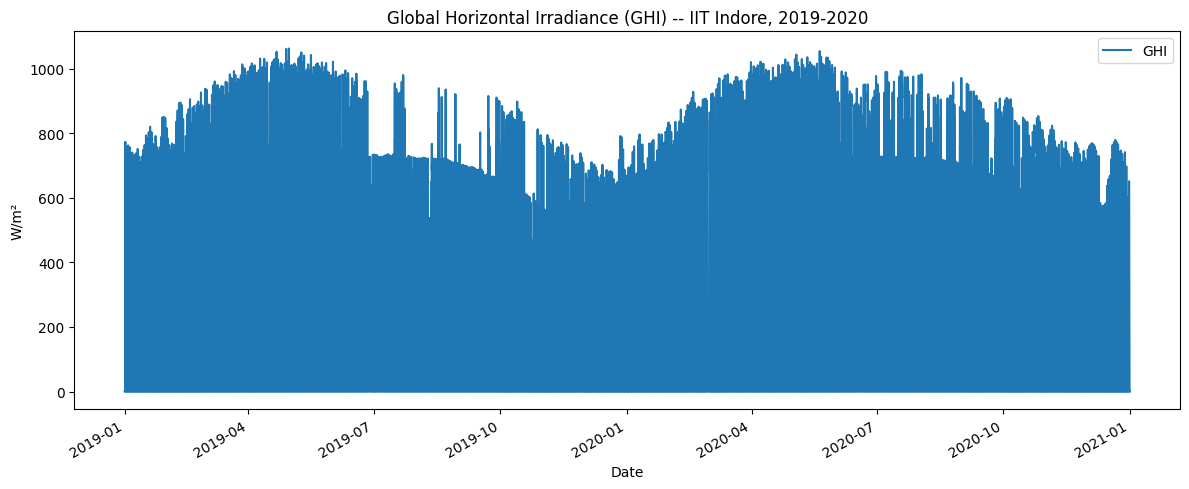

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Note: unlike a single-year raw download (which has a 2-line
# metadata header), the combined file written by the fetch cell
# above was already parsed+concatenated in pandas, so it has a
# clean header row with no metadata lines to skip.
df = pd.read_csv("himawari_2019_2020_data.csv")
print(df.columns.tolist())
print("Years present:", sorted(df['Year'].unique()))

df['Timestamp'] = pd.to_datetime(dict(
    year=df['Year'], month=df['Month'], day=df['Day'],
    hour=df['Hour'], minute=df['Minute']
))
df.set_index('Timestamp', inplace=True)

# Track which calendar days have real source data (>=100 of the ~144
# expected 10-min readings), so Feb 29 (and any other gap) can be
# excluded from any later resampled/daily series -- not just left as
# a silent zero.
rows_per_day = df.groupby(df.index.date).size()
valid_days = set(rows_per_day[rows_per_day >= 100].index)
print(f"\nTotal rows: {len(df)}  |  Valid days: {len(valid_days)}  |  "
      f"(730 expected for 2 clean 365-day years)")

plt.figure(figsize=(12, 5))
df['GHI'].plot(label='GHI')
plt.title("Global Horizontal Irradiance (GHI) -- IIT Indore, 2019-2020")
plt.ylabel("W/m²")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

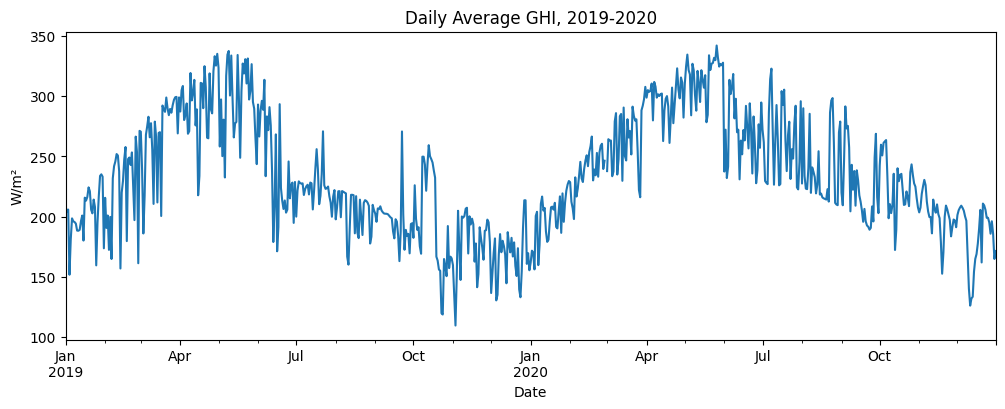

In [5]:
df['GHI'].resample('D').mean().plot(figsize=(12, 4), title='Daily Average GHI, 2019-2020')
plt.ylabel('W/m²')
plt.xlabel('Date')
plt.show()

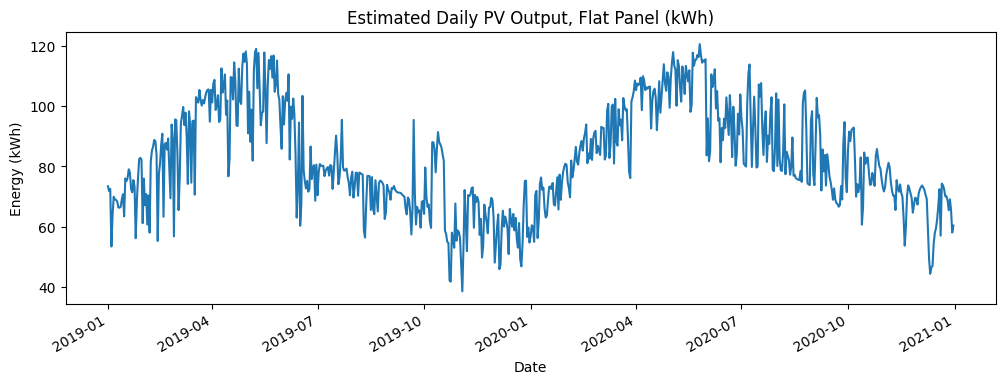

2019 annual: 28,843 kWh
2020 annual: 31,296 kWh
2-year total: 60,139 kWh


In [6]:
panel_area = 1.6
panel_efficiency = 0.18
num_panels = 10
derating_factor = 0.85

df['PV_flat_kw'] = (
    df['GHI'] * panel_area * num_panels * panel_efficiency * derating_factor
) / 1000

def clean_daily(series):
    """Resample to daily sums, then drop any day without real source
    data (e.g. Feb 29 under leap_day=false) instead of leaving a fake
    zero in the series."""
    daily = series.resample('D').sum()
    daily.index = daily.index.date
    daily = daily[daily.index.isin(valid_days)]
    daily.index = pd.to_datetime(daily.index)
    return daily

daily_flat = clean_daily(df['PV_flat_kw'])
daily_flat.plot(figsize=(12, 4), title="Estimated Daily PV Output, Flat Panel (kWh)")
plt.ylabel("Energy (kWh)")
plt.xlabel("Date")
plt.show()

print(f"2019 annual: {daily_flat['2019'].sum():,.0f} kWh")
print(f"2020 annual: {daily_flat['2020'].sum():,.0f} kWh")
print(f"2-year total: {daily_flat.sum():,.0f} kWh")

In [7]:
df['T_cell'] = df['Temperature'] + (df['GHI'] / 800) * 20  # simple NOCT-style estimate
temp_coeff = 0.004  # ~0.4% efficiency loss per C above 25 (named distinctly
# from 'beta' used for tilt angle later -- both conventionally use the
# symbol beta, but they're unrelated quantities; a real bug earlier in
# this project came from reusing the same variable name for both)

df['eff_temp'] = panel_efficiency * (1 - temp_coeff * (df['T_cell'] - 25))
df['PV_output_kw_temp'] = (
    df['GHI'] * panel_area * num_panels * df['eff_temp'] * derating_factor
) / 1000

daily_energy_temp = clean_daily(df['PV_output_kw_temp'])
print(f"Base model (no temp correction): {daily_flat.sum():,.0f} kWh")
print(f"Temperature-adjusted:            {daily_energy_temp.sum():,.0f} kWh")
print(f"Loss from heat: {(1-daily_energy_temp.sum()/daily_flat.sum())*100:.1f}%")

Base model (no temp correction): 60,139 kWh
Temperature-adjusted:            54,788 kWh
Loss from heat: 8.9%


In [8]:
lat = 22.5297  # IIT Indore
lat_rad = np.radians(lat)

doy = df.index.dayofyear.values
decl_rad = np.radians(23.45 * np.sin(np.radians(360 * (284 + doy) / 365)))  # Cooper's equation
solar_time = df['Hour'].values + df['Minute'].values / 60
hour_angle_rad = np.radians(15 * (solar_time - 12))

cos_zenith = (np.sin(lat_rad) * np.sin(decl_rad) +
              np.cos(lat_rad) * np.cos(decl_rad) * np.cos(hour_angle_rad))
computed_zenith_deg = np.degrees(np.arccos(np.clip(cos_zenith, -1, 1)))

mean_abs_error = np.mean(np.abs(computed_zenith_deg - df['Solar Zenith Angle'].values))
print(f"Mean absolute error vs measured Solar Zenith Angle: {mean_abs_error:.2f} degrees")
print("(small, expected error from skipping the equation-of-time correction)")

Mean absolute error vs measured Solar Zenith Angle: 1.46 degrees
(small, expected error from skipping the equation-of-time correction)


Flat annual:   60,139 kWh
Tilted annual: 62,570 kWh
Gain: +4.04%


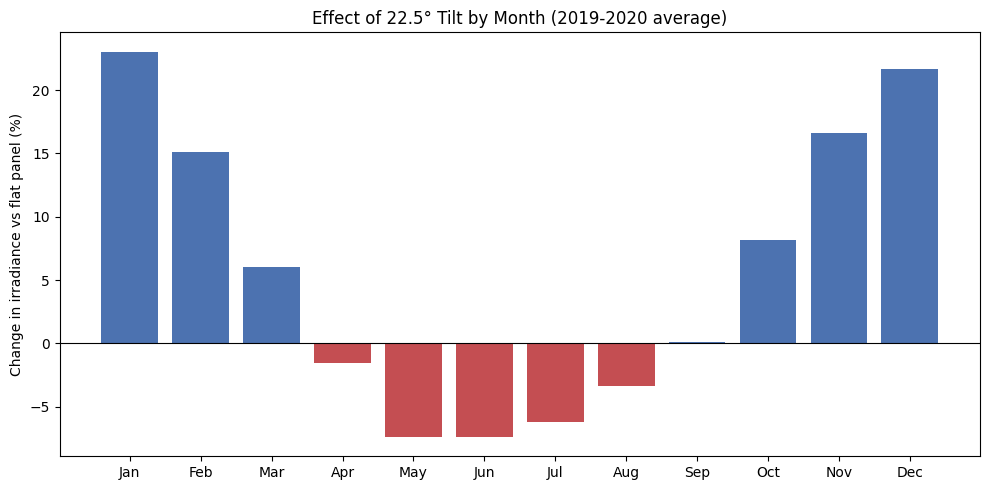

In [9]:
beta = lat_rad  # tilt angle = latitude (standard rule of thumb), due south facing

cos_theta = (np.sin(decl_rad) * np.sin(lat_rad - beta) +
             np.cos(decl_rad) * np.cos(hour_angle_rad) * np.cos(lat_rad - beta))
cos_theta = np.clip(cos_theta, 0, None)

albedo = np.nan_to_num(df['Surface Albedo'].values, nan=0.2)
beam_tilted = df['DNI'].values * cos_theta
diffuse_tilted = df['DHI'].values * (1 + np.cos(beta)) / 2
reflected_tilted = df['GHI'].values * albedo * (1 - np.cos(beta)) / 2
df['POA'] = np.clip(beam_tilted + diffuse_tilted + reflected_tilted, 0, None)

df['PV_tilted_kw'] = (df['POA'] * panel_area * num_panels * panel_efficiency * derating_factor) / 1000
daily_tilted = clean_daily(df['PV_tilted_kw'])

print(f"Flat annual:   {daily_flat.sum():,.0f} kWh")
print(f"Tilted annual: {daily_tilted.sum():,.0f} kWh")
print(f"Gain: {(daily_tilted.sum()/daily_flat.sum()-1)*100:+.2f}%")

monthly = df.groupby(df.index.month)[['GHI', 'POA']].mean()
monthly['pct_change'] = (monthly['POA'] / monthly['GHI'] - 1) * 100
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0' if v >= 0 else '#C44E52' for v in monthly['pct_change']]
ax.bar(months, monthly['pct_change'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Change in irradiance vs flat panel (%)")
ax.set_title(f"Effect of {lat:.1f}° Tilt by Month (2019-2020 average)")
plt.tight_layout()
plt.show()

In [10]:
T_cell_combined = df['Temperature'] + (df['POA'] / 800) * 20
eff_combined = panel_efficiency * (1 - temp_coeff * (T_cell_combined - 25))
df['PV_combined_kw'] = (df['POA'] * panel_area * num_panels * eff_combined * derating_factor) / 1000

daily_combined = clean_daily(df['PV_combined_kw'])

print(f"Flat, no correction:    {daily_flat.sum():,.0f} kWh")
print(f"Tilt only:               {daily_tilted.sum():,.0f} kWh ({(daily_tilted.sum()/daily_flat.sum()-1)*100:+.2f}%)")
print(f"Temperature only:        {daily_energy_temp.sum():,.0f} kWh ({(daily_energy_temp.sum()/daily_flat.sum()-1)*100:+.2f}%)")
print(f"Combined (tilt + temp):  {daily_combined.sum():,.0f} kWh ({(daily_combined.sum()/daily_flat.sum()-1)*100:+.2f}%)")
print(f"\n2019 combined: {daily_combined['2019'].sum():,.0f} kWh")
print(f"2020 combined: {daily_combined['2020'].sum():,.0f} kWh")

Flat, no correction:    60,139 kWh
Tilt only:               62,570 kWh (+4.04%)
Temperature only:        54,788 kWh (-8.90%)
Combined (tilt + temp):  56,918 kWh (-5.36%)

2019 combined: 27,242 kWh
2020 combined: 29,676 kWh


Clear Sky Index -- 2-year mean: 0.877
1     0.972
2     0.950
3     0.944
4     0.948
5     0.942
6     0.803
7     0.775
8     0.716
9     0.748
10    0.864
11    0.929
12    0.939
dtype: float64


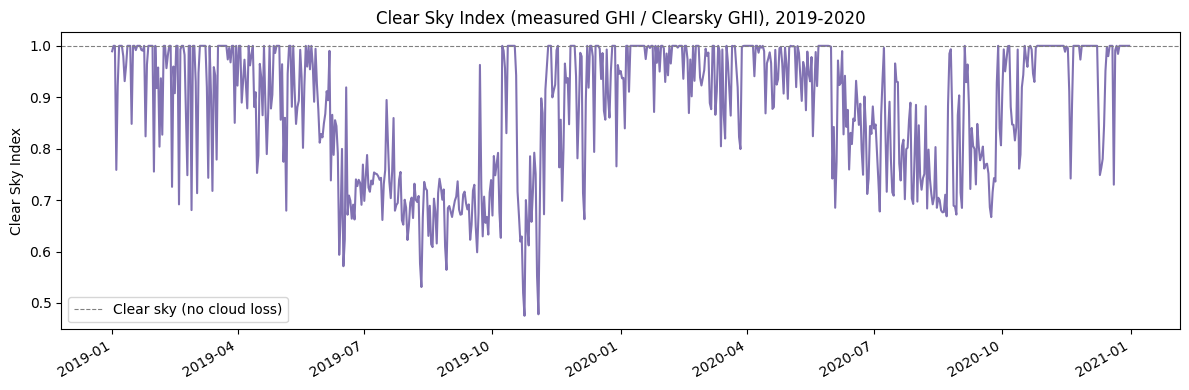

In [11]:
csi = (df['GHI'] / df['Clearsky GHI'].replace(0, np.nan)).resample('D').mean()
csi.index = csi.index.date
csi = csi[csi.index.isin(valid_days)]
csi.index = pd.to_datetime(csi.index)

print(f"Clear Sky Index -- 2-year mean: {csi.mean():.3f}")
print(csi.groupby(csi.index.month).mean().round(3))

fig, ax = plt.subplots(figsize=(12, 4))
csi.plot(ax=ax, color='#8172B2')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='Clear sky (no cloud loss)')
ax.set_ylabel("Clear Sky Index")
ax.set_title("Clear Sky Index (measured GHI / Clearsky GHI), 2019-2020")
ax.legend()
plt.tight_layout()
plt.show()

Overall: 24.8% of rows are filled/interpolated

By month (% filled), averaged across 2019-2020:
Timestamp
1     10.1
2      8.4
3     12.8
4     15.5
5     15.5
6     43.2
7     48.5
8     51.2
9     45.7
10    23.8
11    10.6
12    11.6
Name: Fill Flag, dtype: float64

Fill rate jumps sharply in monsoon months (Jun-Sep) in both years --
heavy cloud cover makes satellite retrieval harder.


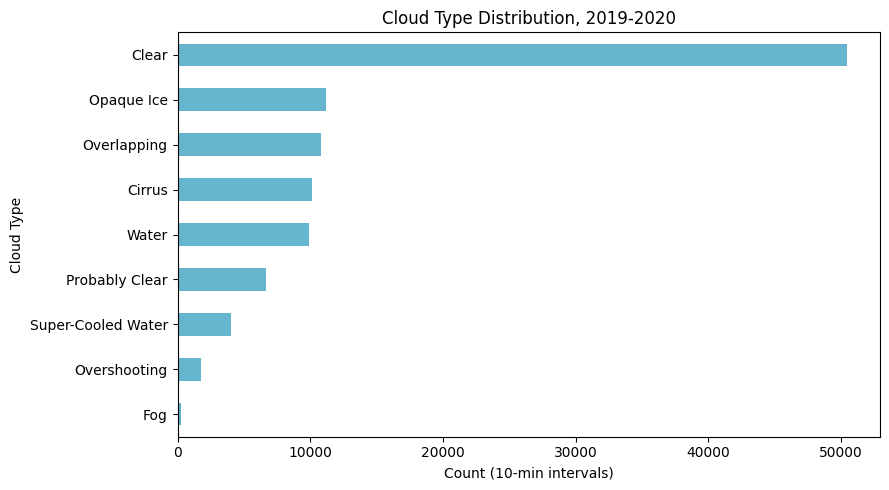

In [12]:
fill_pct = (df['Fill Flag'] != 0).mean() * 100
print(f"Overall: {fill_pct:.1f}% of rows are filled/interpolated\n")

fill_by_month = (df['Fill Flag'] != 0).groupby(df.index.month).mean() * 100
print("By month (% filled), averaged across 2019-2020:")
print(fill_by_month.round(1))
print("\nFill rate jumps sharply in monsoon months (Jun-Sep) in both years --")
print("heavy cloud cover makes satellite retrieval harder.")

cloud_labels = {0:'Clear', 1:'Probably Clear', 2:'Fog', 3:'Water', 4:'Super-Cooled Water',
                5:'Mixed', 6:'Opaque Ice', 7:'Cirrus', 8:'Overlapping', 9:'Overshooting'}
cloud_counts = df['Cloud Type'].map(cloud_labels).value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
cloud_counts.sort_values().plot(kind='barh', ax=ax, color='#64B5CD')
ax.set_xlabel("Count (10-min intervals)")
ax.set_title("Cloud Type Distribution, 2019-2020")
plt.tight_layout()
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


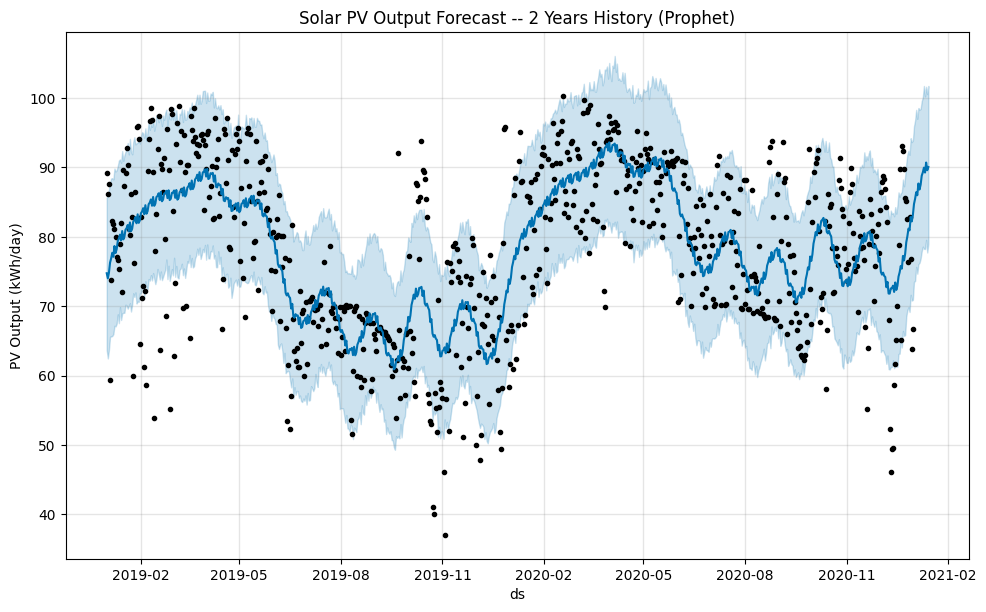

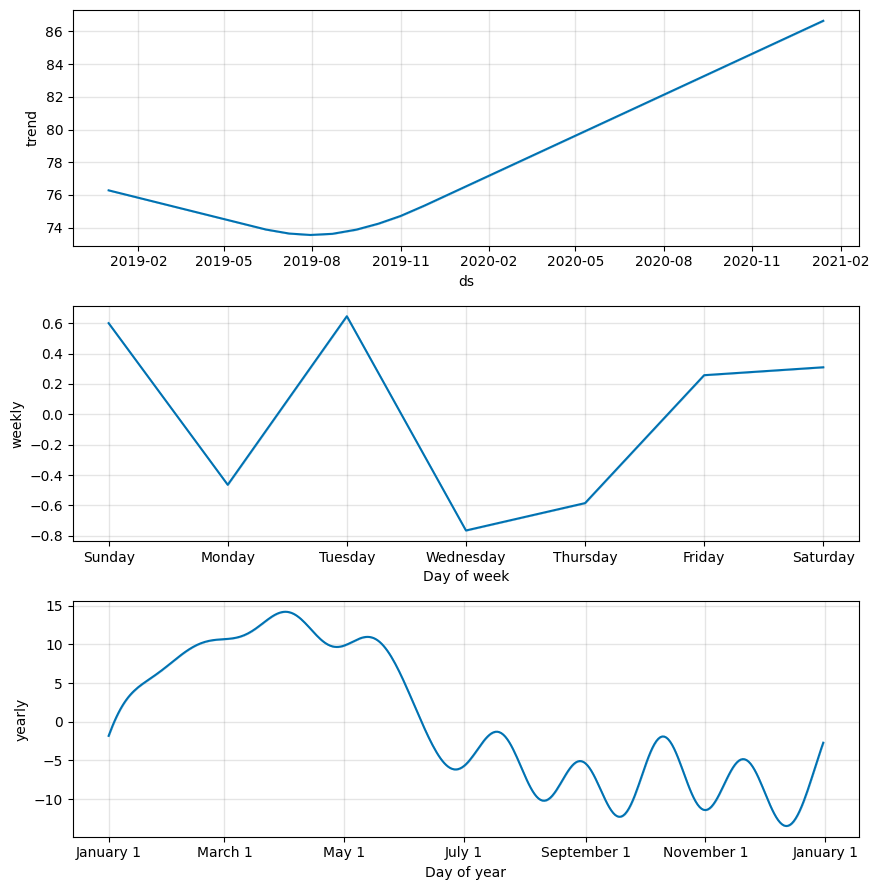

In [13]:
from prophet import Prophet

df_prophet = daily_combined.reset_index()
df_prophet.columns = ['ds', 'y']

model = Prophet(yearly_seasonality=True)
model.fit(df_prophet)

future = model.make_future_dataframe(periods=14, freq='D')
forecast = model.predict(future)

model.plot(forecast)
plt.title("Solar PV Output Forecast -- 2 Years History (Prophet)")
plt.ylabel("PV Output (kWh/day)")
plt.show()

model.plot_components(forecast)
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Trained on 2019 (365 days) -> tested on real 2020 (365 days)
MAE:  21.70 kWh
RMSE: 23.67 kWh
MAPE: 26.3%
% of actual 2020 values within Prophet's 80% CI: 14.8%  (should be ~80% if well-calibrated)


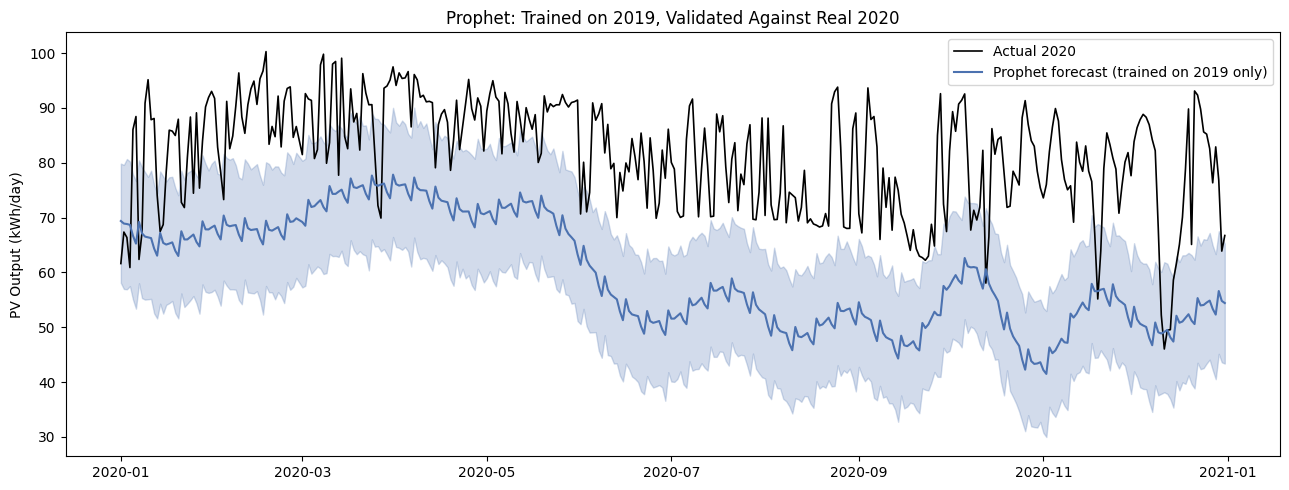

In [14]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

train = daily_combined['2019']
test = daily_combined['2020']

df_train = train.reset_index()
df_train.columns = ['ds', 'y']

model_2019 = Prophet(yearly_seasonality=True)
model_2019.fit(df_train)

# Predict directly on the exact test dates (robust to the Feb 29 gap,
# rather than relying on a day-count that would misalign by one day)
future_2020 = pd.DataFrame({'ds': test.index})
forecast_2020 = model_2019.predict(future_2020).set_index('ds')

mae = mean_absolute_error(test, forecast_2020['yhat'])
rmse = np.sqrt(np.mean((test.values - forecast_2020['yhat'].values)**2))
mape = mean_absolute_percentage_error(test, forecast_2020['yhat']) * 100
within_ci = ((test.values >= forecast_2020['yhat_lower'].values) &
             (test.values <= forecast_2020['yhat_upper'].values)).mean() * 100

print(f"Trained on 2019 ({len(train)} days) -> tested on real 2020 ({len(test)} days)")
print(f"MAE:  {mae:.2f} kWh")
print(f"RMSE: {rmse:.2f} kWh")
print(f"MAPE: {mape:.1f}%")
print(f"% of actual 2020 values within Prophet's 80% CI: {within_ci:.1f}%  (should be ~80% if well-calibrated)")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test.index, test.values, label='Actual 2020', color='black', linewidth=1.2)
ax.plot(forecast_2020.index, forecast_2020['yhat'], label='Prophet forecast (trained on 2019 only)', color='#4C72B0')
ax.fill_between(forecast_2020.index, forecast_2020['yhat_lower'], forecast_2020['yhat_upper'], alpha=0.25, color='#4C72B0')
ax.set_ylabel("PV Output (kWh/day)")
ax.set_title("Prophet: Trained on 2019, Validated Against Real 2020")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
monsoon_2019 = daily_combined['2019-06':'2019-09']
monsoon_2020 = daily_combined['2020-06':'2020-09']

print(f"2019 monsoon (Jun-Sep) mean daily output: {monsoon_2019.mean():.1f} kWh")
print(f"2020 monsoon (Jun-Sep) mean daily output: {monsoon_2020.mean():.1f} kWh")
print(f"2020's monsoon was {(monsoon_2020.mean()/monsoon_2019.mean()-1)*100:+.1f}% vs 2019's")
print(f"\n2019 full-year mean: {daily_combined['2019'].mean():.1f} kWh/day")
print(f"2020 full-year mean: {daily_combined['2020'].mean():.1f} kWh/day")
print("\nThis is real year-to-year monsoon variability, not a data error --")
print("India's monsoon intensity genuinely varies year to year. A model")
print("trained on only one year's monsoon severity has no way to know")
print("whether the next year's will be similar -- exactly why the wide,")
print("poorly-calibrated confidence interval above happens: Prophet is")
print("honestly uncertain, and the single training year undersold how")
print("uncertain it should actually be about monsoon intensity.")

2019 monsoon (Jun-Sep) mean daily output: 67.3 kWh
2020 monsoon (Jun-Sep) mean daily output: 76.8 kWh
2020's monsoon was +14.2% vs 2019's

2019 full-year mean: 74.6 kWh/day
2020 full-year mean: 81.3 kWh/day

This is real year-to-year monsoon variability, not a data error --
India's monsoon intensity genuinely varies year to year. A model
trained on only one year's monsoon severity has no way to know
whether the next year's will be similar -- exactly why the wide,
poorly-calibrated confidence interval above happens: Prophet is
honestly uncertain, and the single training year undersold how
uncertain it should actually be about monsoon intensity.
